In [1]:
import os
import sys
import glob
import mne
import pandas as pd
import matplotlib.pyplot as plt

# Ensure inline plotting for Jupyter
%matplotlib inline

# Since the notebook is in /preprocessing/mat_preprocessing, 
# we step two folders up ('../../') to reach the main FM_SVM_Riemannian folder where config.py is located.
sys.path.append(os.path.abspath("../../"))
import config

In [2]:
# ==============================================================================
# CELL 2: FIND FILES USING MODERN PATHLIB
# ==============================================================================
# We use the pathlib Path object directly from the config
base_output_dir = config.FM_DIR / "derivatives"

# Print the exact path to verify Python is looking in the right place
print(f"🔍 Searching for files inside: {base_output_dir}")

# Use .rglob() to recursively find all .vhdr files in any subfolder
# We convert them to strings so MNE-Python can read them easily in the next cell
vhdr_files = sorted([str(path) for path in base_output_dir.rglob("*.vhdr")])

print(f"✅ Total .vhdr files found: {len(vhdr_files)}")

if len(vhdr_files) > 0:
    print("\nFirst 5 files in the pipeline:")
    for f in vhdr_files[:5]:
        # Print the relative path for a clean overview
        print(f"  ➔ {os.path.relpath(f, base_output_dir)}")
else:
    print("⚠️ WARNING: No files found. Check if the search path above matches your Windows Explorer.")


🔍 Searching for files inside: C:\Users\Jasmyne\Documents\Thesis\Data\FM_EO_dataset\derivatives
✅ Total .vhdr files found: 51

First 5 files in the pipeline:
  ➔ sub-FM001\ses-1\eeg\sub-FM001_task-EO_eeg.vhdr
  ➔ sub-FM002\ses-1\eeg\sub-FM002_task-EO_eeg.vhdr
  ➔ sub-FM003\ses-1\eeg\sub-FM003_task-EO_eeg.vhdr
  ➔ sub-FM004\ses-1\eeg\sub-FM004_task-EO_eeg.vhdr
  ➔ sub-FM005\ses-1\eeg\sub-FM005_task-EO_eeg.vhdr


In [3]:
if len(vhdr_files) > 0:
    # Safely select the first file
    test_file = vhdr_files[0]
    print(f"Loading file: {os.path.basename(test_file)}\n")

    # Load raw data into RAM for visualization
    raw = mne.io.read_raw_brainvision(test_file, preload=True, verbose='ERROR')
    
    # FIX: Dynamically filter the renaming map to only include channels present in the data
    valid_mapping = {
        old_name: new_name 
        for old_name, new_name in config.CHANNEL_RENAMING_MAP.items() 
        if old_name in raw.ch_names
    }
    
    # Apply channel renaming safely
    if valid_mapping:
        raw.rename_channels(valid_mapping)
    
    # Display the interactive MNE info table
    display(raw.info)

Loading file: sub-FM001_task-EO_eeg.vhdr



<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, AF7, AF3, AF4, AF8, F7, F5, F3, F1, Fz, F2, F4, ...
 chs: 60 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 60
 projs: []
 sfreq: 250.0 Hz
>

In [4]:
if len(vhdr_files) > 0:
    # Convert BrainVision markers (.vmrk) to MNE Annotations
    events, event_id = mne.events_from_annotations(raw, verbose='ERROR')

    print(f"Total trials/epochs found in this run: {len(events)}")
    print(f"Event ID mapping (Trigger codes): {event_id}\n")

    # Present the first 10 markers in a clear Pandas DataFrame
    df_events = pd.DataFrame(events, columns=['Sample_Onset', 'Placeholder', 'Trigger_Value'])
    display(df_events.head(10))

Total trials/epochs found in this run: 96
Event ID mapping (Trigger codes): {np.str_('Stimulus/S  1'): 1, np.str_('Stimulus/S  2'): 2, np.str_('Stimulus/S  3'): 3, np.str_('Stimulus/S  4'): 4, np.str_('Stimulus/S  5'): 5, np.str_('Stimulus/S  6'): 6, np.str_('Stimulus/S  7'): 7, np.str_('Stimulus/S  8'): 8, np.str_('Stimulus/S  9'): 9, np.str_('Stimulus/S 10'): 10, np.str_('Stimulus/S 11'): 11, np.str_('Stimulus/S 12'): 12, np.str_('Stimulus/S 13'): 13, np.str_('Stimulus/S 14'): 14, np.str_('Stimulus/S 15'): 15, np.str_('Stimulus/S 16'): 16, np.str_('Stimulus/S 17'): 17, np.str_('Stimulus/S 18'): 18, np.str_('Stimulus/S 19'): 19, np.str_('Stimulus/S 20'): 20, np.str_('Stimulus/S 21'): 21, np.str_('Stimulus/S 22'): 22, np.str_('Stimulus/S 23'): 23, np.str_('Stimulus/S 24'): 24, np.str_('Stimulus/S 25'): 25, np.str_('Stimulus/S 26'): 26, np.str_('Stimulus/S 27'): 27, np.str_('Stimulus/S 28'): 28, np.str_('Stimulus/S 29'): 29, np.str_('Stimulus/S 30'): 30, np.str_('Stimulus/S 31'): 31, np

,Sample_Onset,Placeholder,Trigger_Value
0,0,0,1
1,337,0,2
2,674,0,3
3,1011,0,4
4,1348,0,5
5,1685,0,6
6,2022,0,7
7,2359,0,8
8,2696,0,9
9,3033,0,10



📊 PSD Plot for: sub-FM001
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


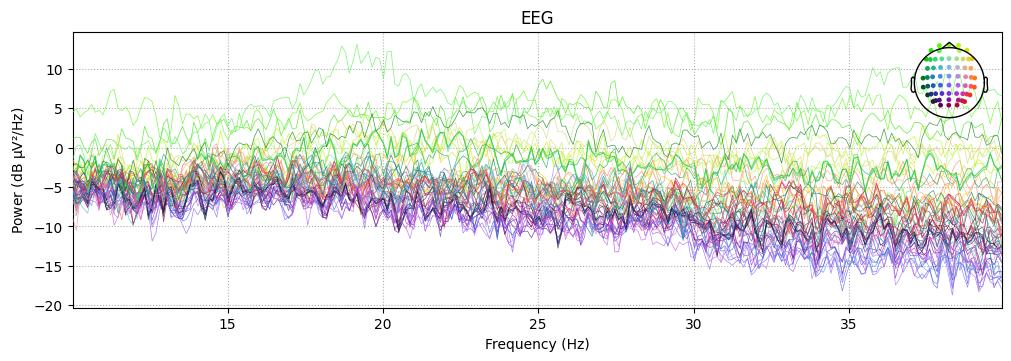


📊 PSD Plot for: sub-HC001
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


c:\Users\Jasmyne\anaconda3\envs\vsc\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


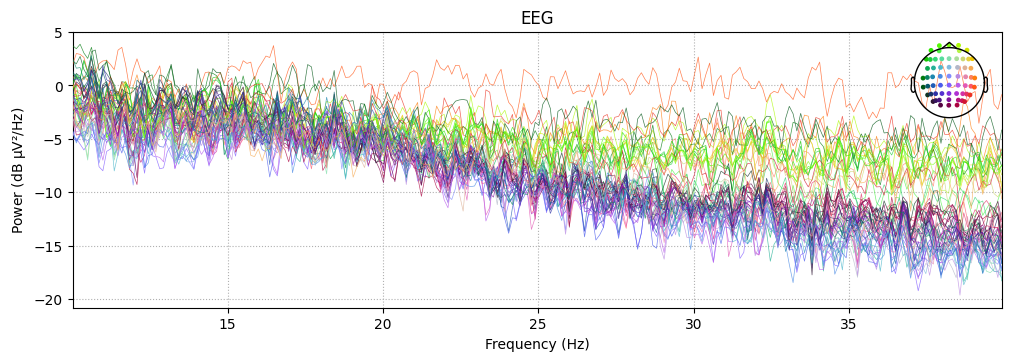

In [5]:
# ==============================================================================
# CELL 5: AUTOMATED PSD & SPATIAL COLORS FOR FM AND HC
# ==============================================================================
def plot_subject_psd(file_path):
    """
    Loads an EEG file, applies standard 10-20 montage, and plots the PSD with spatial colors.
    """
    subject_id = os.path.basename(file_path).split('_')[0]
    print(f"\n{'='*50}\n📊 PSD Plot for: {subject_id}\n{'='*50}")
    
    # Load data
    raw_data = mne.io.read_raw_brainvision(file_path, preload=True, verbose='ERROR')
    
    # FIX: Dynamically filter the renaming map to only include channels present in this data
    valid_mapping = {
        old_name: new_name 
        for old_name, new_name in config.CHANNEL_RENAMING_MAP.items() 
        if old_name in raw_data.ch_names
    }
    
    # Apply channel renaming safely directly on the raw object
    if valid_mapping:
        raw_data.rename_channels(valid_mapping)
    
    # CRITICAL: Link 3D coordinates to channel names (10-20 system)
    montage = mne.channels.make_standard_montage('standard_1020')
    raw_data.set_montage(montage, on_missing='warn')
    
    # Compute Power Spectral Density (PSD)
    # Kept within 0.5 - 50 Hz to match the original study filtering
    spectrum = raw_data.compute_psd(fmin=10, fmax=40)
    
    # Plot with spatial colors and topographical inset
    spectrum.plot(spatial_colors=True)
    plt.show()

# Find the first Fibromyalgia patient and first Healthy Control dynamically
fm_test_file = next((f for f in vhdr_files if "sub-FM" in f), None)
hc_test_file = next((f for f in vhdr_files if "sub-HC" in f), None)

if fm_test_file:
    plot_subject_psd(fm_test_file)
else:
    print("No FM subjects found to plot.")
    
if hc_test_file:
    plot_subject_psd(hc_test_file)
else:
    print("No HC subjects found to plot.")